In [3]:
!pip install google

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 935.7 kB/s eta 0:00:000:00:01


In [13]:
!pip install matplotlib

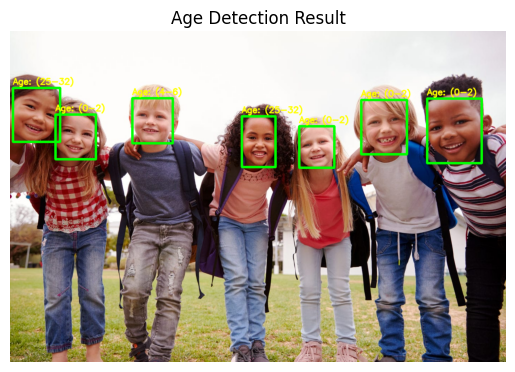

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Model files
# -------------------------------
face_proto = "opencv_face_detector.pbtxt"
face_model = "opencv_face_detector_uint8.pb"
age_proto = "age_deploy.prototxt"
age_model = "age_net.caffemodel"

# -------------------------------
# Load models
# -------------------------------
face_net = cv2.dnn.readNetFromTensorflow(face_model, face_proto)
age_net = cv2.dnn.readNetFromCaffe(age_proto, age_model)

# -------------------------------
# Constants (MISSING in your code)
# -------------------------------
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)

age_list = [
    '(0-2)', '(4-6)', '(8-12)', '(15-20)',
    '(25-32)', '(38-43)', '(48-53)', '(60-100)'
]

# -------------------------------
# Face Detection
# -------------------------------
def detect_faces(net, frame, conf_threshold=0.7):
    frame_height = frame.shape[0]
    frame_width = frame.shape[1]

    blob = cv2.dnn.blobFromImage(
        frame, 1.0, (300, 300),
        [104, 117, 123], False, False
    )

    net.setInput(blob)
    detections = net.forward()

    face_boxes = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frame_width)
            y1 = int(detections[0, 0, i, 4] * frame_height)
            x2 = int(detections[0, 0, i, 5] * frame_width)
            y2 = int(detections[0, 0, i, 6] * frame_height)

            face_boxes.append([x1, y1, x2, y2])

            cv2.rectangle(
                frame, (x1, y1), (x2, y2),
                (0, 255, 0), int(round(frame_height / 150)), 8
            )

    return frame, face_boxes

# -------------------------------
# Age Prediction
# -------------------------------
def predict_age(face, net):
    blob = cv2.dnn.blobFromImage(
        face, 1.0, (227, 227),
        MODEL_MEAN_VALUES, swapRB=False
    )

    net.setInput(blob)
    age_preds = net.forward()

    age = age_list[age_preds[0].argmax()]
    return age

# -------------------------------
# Process Image
# -------------------------------
def process_image(image_path):
    frame = cv2.imread(image_path)

    if frame is None:
        print(f"❌ Error: Image not found at {image_path}")
        return

    frame, face_boxes = detect_faces(face_net, frame)

    if not face_boxes:
        print("⚠️ No faces detected")

    for (x1, y1, x2, y2) in face_boxes:
        face = frame[
            max(0, y1 - 20):min(y2 + 20, frame.shape[0] - 1),
            max(0, x1 - 20):min(x2 + 20, frame.shape[1] - 1)
        ]

        age = predict_age(face, age_net)

        cv2.putText(
            frame,
            f"Age: {age}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 255),
            2,
            cv2.LINE_AA
        )

    # -------------------------------
    # Display using matplotlib (BEST for notebooks)
    # -------------------------------
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Age Detection Result")
    plt.axis('off')
    plt.show()

# -------------------------------
# Run
# -------------------------------
image_path = "kid5.jpg"  # change path if needed
process_image(image_path)